# AdventureWorks Sales – 02 Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on precomputed sales DataFrames from SQL Server (monthly sales, top products, and territory performance).


In [122]:
import sqlalchemy as sa
import urllib
import pandas as pd

# Connection details
server = r"MYDELL23\SQLEXPRESS01"
database = "AdventureWorks"

conn_str = (
    "Driver={ODBC Driver 17 for SQL Server};"
    f"Server={server};"
    f"Database={database};"
    "Trusted_Connection=yes;"
)

params = urllib.parse.quote_plus(conn_str)
engine = sa.create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

def run_query(sql: str) -> pd.DataFrame:
    """Run a SQL query against AdventureWorks and return a DataFrame."""
    return pd.read_sql(sql, engine)


In [123]:
sql_monthly_top10 = """
SELECT TOP 10
    CONVERT(date, DATEFROMPARTS(YEAR(soh.OrderDate), MONTH(soh.OrderDate), 1)) AS MonthStart,
    SUM(sod.LineTotal) AS TotalSales
FROM Sales.SalesOrderHeader AS soh
JOIN Sales.SalesOrderDetail AS sod
    ON soh.SalesOrderID = sod.SalesOrderID
GROUP BY
    YEAR(soh.OrderDate),
    MONTH(soh.OrderDate)
ORDER BY TotalSales DESC;
"""

df_monthly_top10 = run_query(sql_monthly_top10)
df_monthly_top10.head()


,MonthStart,TotalSales
0,2014-03-01,"7,217,531.09"
1,2014-05-01,"5,366,674.97"
2,2013-06-01,"5,081,069.13"
3,2013-07-01,"4,896,353.74"
4,2013-10-01,"4,795,813.29"


In [124]:
sql_top_products = """
SELECT TOP 10
    p.Name AS ProductName,
    SUM(sod.LineTotal) AS TotalSales,
    SUM(sod.OrderQty) AS TotalQuantity,
    COUNT(DISTINCT sod.SalesOrderID) AS OrderCount
FROM Sales.SalesOrderDetail AS sod
JOIN Production.Product AS p
    ON sod.ProductID = p.ProductID
GROUP BY
    p.Name
ORDER BY TotalSales DESC;
"""
df_top_products = run_query(sql_top_products)
df_top_products.head()


,ProductName,TotalSales,TotalQuantity,OrderCount
0,"Mountain-200 Black, 38","4,400,592.80",2977,1252
1,"Mountain-200 Black, 42","4,009,494.76",2664,1177
2,"Mountain-200 Silver, 38","3,693,678.03",2394,1094
3,"Mountain-200 Silver, 42","3,438,478.86",2234,1040
4,"Mountain-200 Silver, 46","3,434,256.94",2216,1054


In [125]:
sql_territory_sales = """
SELECT TOP 10
    st.Name AS TerritoryName,
    SUM(soh.SubTotal) AS TotalSales,
    COUNT(DISTINCT soh.SalesOrderID) AS OrderCount,
    AVG(soh.SubTotal) AS AvgOrderValue
FROM Sales.SalesOrderHeader AS soh
JOIN Sales.SalesTerritory AS st
    ON soh.TerritoryID = st.TerritoryID
GROUP BY
    st.Name
ORDER BY TotalSales DESC;
"""

df_territory_sales = run_query(sql_territory_sales)
df_territory_sales.head()


,TerritoryName,TotalSales,OrderCount,AvgOrderValue
0,Southwest,"24,184,609.60",6224,"3,885.70"
1,Canada,"16,355,770.46",4067,"4,021.58"
2,Northwest,"16,084,942.55",4594,"3,501.29"
3,Australia,"10,655,335.96",6843,"1,557.11"
4,Central,"7,909,009.01",385,"20,542.88"


## Data overview

Quick structural checks for the three core sales DataFrames used in this EDA:
- `df_monthly_top10`: top 10 months by total sales.
- `df_top_products`: top 10 products by sales, quantity, and order count.
- `df_territory_sales`: top 10 territories by total sales and average order value.


In [126]:
print("df_monthly_top10:", df_monthly_top10.shape)
display(df_monthly_top10.head(10))

print("\ndf_top_products:", df_top_products.shape)
display(df_top_products.head(10))

print("\ndf_territory_sales:", df_territory_sales.shape)
display(df_territory_sales.head(10))


df_monthly_top10: (10, 2)


,MonthStart,TotalSales
0,2014-03-01,"7,217,531.09"
1,2014-05-01,"5,366,674.97"
2,2013-06-01,"5,081,069.13"
3,2013-07-01,"4,896,353.74"
4,2013-10-01,"4,795,813.29"
5,2011-10-01,"4,588,761.82"
6,2013-09-01,"4,532,908.71"
7,2014-01-01,"4,289,817.95"
8,2012-06-01,"4,099,354.36"
9,2013-12-01,"4,075,486.63"



df_top_products: (10, 4)


,ProductName,TotalSales,TotalQuantity,OrderCount
0,"Mountain-200 Black, 38","4,400,592.80",2977,1252
1,"Mountain-200 Black, 42","4,009,494.76",2664,1177
2,"Mountain-200 Silver, 38","3,693,678.03",2394,1094
3,"Mountain-200 Silver, 42","3,438,478.86",2234,1040
4,"Mountain-200 Silver, 46","3,434,256.94",2216,1054
5,"Mountain-200 Black, 46","3,309,673.22",2111,1059
6,"Road-250 Black, 44","2,516,857.31",1642,705
7,"Road-250 Black, 48","2,347,655.95",1498,712
8,"Road-250 Black, 52","2,012,447.77",1245,667
9,"Road-150 Red, 56","1,847,818.63",664,475



df_territory_sales: (10, 4)


,TerritoryName,TotalSales,OrderCount,AvgOrderValue
0,Southwest,"24,184,609.60",6224,"3,885.70"
1,Canada,"16,355,770.46",4067,"4,021.58"
2,Northwest,"16,084,942.55",4594,"3,501.29"
3,Australia,"10,655,335.96",6843,"1,557.11"
4,Central,"7,909,009.01",385,"20,542.88"
5,Southeast,"7,879,655.07",486,"16,213.28"
6,United Kingdom,"7,670,721.04",3219,"2,382.95"
7,France,"7,251,555.65",2672,"2,713.91"
8,Northeast,"6,939,374.48",352,"19,714.13"
9,Germany,"4,915,407.60",2623,"1,873.96"


## Structural and summary checks

Check dtypes, basic statistics, and missing values for each DataFrame to confirm the data is clean and numeric columns behave as expected.


In [127]:
def summarize_df(df, name):
    print(f"=== {name} ===")
    display(df.info())
    display(df.describe(include="all"))
    print("\nMissing values:")
    display(df.isna().sum())
    print("\n" + "-" * 60 + "\n")

summarize_df(df_monthly_top10, "df_monthly_top10")
summarize_df(df_top_products, "df_top_products")
summarize_df(df_territory_sales, "df_territory_sales")


=== df_monthly_top10 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MonthStart  10 non-null     object 
 1   TotalSales  10 non-null     float64
dtypes: float64(1), object(1)
memory usage: 292.0+ bytes


None

,MonthStart,TotalSales
count,10,10.00
unique,10,NaN
top,2014-03-01,NaN
freq,1,NaN
mean,NaN,"4,894,377.17"
std,NaN,"916,325.82"
min,NaN,"4,075,486.63"
25%,NaN,"4,350,590.64"
50%,NaN,"4,692,287.55"
75%,NaN,"5,034,890.28"



Missing values:


MonthStart    0
TotalSales    0
dtype: int64

...

None

,TerritoryName,TotalSales,OrderCount,AvgOrderValue
count,10,10.00,10.00,10.00
unique,10,NaN,NaN,NaN
top,Southwest,NaN,NaN,NaN
freq,1,NaN,NaN,NaN
mean,NaN,"10,984,638.14","3,146.50","7,640.68"
std,NaN,"6,022,438.94","2,335.61","7,833.25"
min,NaN,"4,915,407.60",352.00,"1,557.11"
25%,NaN,"7,356,346.99","1,020.25","2,465.69"
50%,NaN,"7,894,332.04","2,945.50","3,693.50"
75%,NaN,"14,727,540.90","4,462.25","13,165.36"



Missing values:


TerritoryName    0
TotalSales       0
OrderCount       0
AvgOrderValue    0
dtype: int64


------------------------------------------------------------



In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:,.2f}".format)


In [129]:
df_top_products.head()

,ProductName,TotalSales,TotalQuantity,OrderCount
0,"Mountain-200 Black, 38","4,400,592.80",2977,1252
1,"Mountain-200 Black, 42","4,009,494.76",2664,1177
2,"Mountain-200 Silver, 38","3,693,678.03",2394,1094
3,"Mountain-200 Silver, 42","3,438,478.86",2234,1040
4,"Mountain-200 Silver, 46","3,434,256.94",2216,1054


In [130]:
df_top_products = df_top_products.copy()

df_top_products["RevenuePerUnit"] = df_top_products["TotalSales"] / df_top_products["TotalQuantity"]
df_top_products["RevenuePerOrder"] = df_top_products["TotalSales"] / df_top_products["OrderCount"]

total_revenue = df_top_products["TotalSales"].sum()
df_top_products["RevenueShare"] = df_top_products["TotalSales"] / total_revenue

df_top_products.head()


,ProductName,TotalSales,TotalQuantity,OrderCount,RevenuePerUnit,RevenuePerOrder,RevenueShare
0,"Mountain-200 Black, 38","4,400,592.80",2977,1252,"1,478.20","3,514.85",0.14
1,"Mountain-200 Black, 42","4,009,494.76",2664,1177,"1,505.07","3,406.54",0.13
2,"Mountain-200 Silver, 38","3,693,678.03",2394,1094,"1,542.89","3,376.31",0.12
3,"Mountain-200 Silver, 42","3,438,478.86",2234,1040,"1,539.16","3,306.23",0.11
4,"Mountain-200 Silver, 46","3,434,256.94",2216,1054,"1,549.75","3,258.31",0.11


In [131]:
import pandas as pd

df_top_products["SalesTier"] = pd.qcut(
    df_top_products["TotalSales"],
    q=3,
    labels=["Low", "Medium", "High"]
)

df_top_products[["ProductName", "TotalSales", "SalesTier"]]


,ProductName,TotalSales,SalesTier
0,"Mountain-200 Black, 38","4,400,592.80",High
1,"Mountain-200 Black, 42","4,009,494.76",High
2,"Mountain-200 Silver, 38","3,693,678.03",High
3,"Mountain-200 Silver, 42","3,438,478.86",Medium
4,"Mountain-200 Silver, 46","3,434,256.94",Medium
5,"Mountain-200 Black, 46","3,309,673.22",Medium
6,"Road-250 Black, 44","2,516,857.31",Low
7,"Road-250 Black, 48","2,347,655.95",Low
8,"Road-250 Black, 52","2,012,447.77",Low
9,"Road-150 Red, 56","1,847,818.63",Low


In [132]:
tier_summary = (
    df_top_products
    .groupby("SalesTier", observed=True)
    .agg(
        Products=("ProductName", "count"),
        TotalSales=("TotalSales", "sum"),
        AvgRevenuePerUnit=("RevenuePerUnit", "mean"),
        AvgRevenuePerOrder=("RevenuePerOrder", "mean"),
        RevenueShare=("RevenueShare", "sum"),
    )
    .sort_values("TotalSales", ascending=False)
)

tier_summary


,Products,TotalSales,AvgRevenuePerUnit,AvgRevenuePerOrder,RevenueShare
SalesTier,,,,,
High,3,"12,103,765.59","1,508.72","3,432.56",0.39
Medium,3,"10,182,409.02","1,552.25","3,229.94",0.33
Low,4,"8,724,779.67","1,874.82","3,443.65",0.28


### Product tier summary

This table compares Low/Medium/High sales tiers by count of products, total revenue, and average revenue per unit/order. It highlights which tier contributes most to overall sales.

In [133]:
df_territory_sales.head()

,TerritoryName,TotalSales,OrderCount,AvgOrderValue
0,Southwest,"24,184,609.60",6224,"3,885.70"
1,Canada,"16,355,770.46",4067,"4,021.58"
2,Northwest,"16,084,942.55",4594,"3,501.29"
3,Australia,"10,655,335.96",6843,"1,557.11"
4,Central,"7,909,009.01",385,"20,542.88"


In [134]:
df_territory_sales = df_territory_sales.copy()

# Revenue per order (sanity check vs AvgOrderValue from SQL)
df_territory_sales["RevenuePerOrder"] = (
    df_territory_sales["TotalSales"] / df_territory_sales["OrderCount"]
)

# Rank territories by TotalSales (1 = highest)
df_territory_sales["SalesRank"] = df_territory_sales["TotalSales"].rank(
    method="dense", ascending=False
)

# Rank territories by AvgOrderValue (1 = highest)
df_territory_sales["AvgOrderValueRank"] = df_territory_sales["AvgOrderValue"].rank(
    method="dense", ascending=False
)

df_territory_sales.head(10)


,TerritoryName,TotalSales,OrderCount,AvgOrderValue,RevenuePerOrder,SalesRank,AvgOrderValueRank
0,Southwest,"24,184,609.60",6224,"3,885.70","3,885.70",1.00,5.00
1,Canada,"16,355,770.46",4067,"4,021.58","4,021.58",2.00,4.00
2,Northwest,"16,084,942.55",4594,"3,501.29","3,501.29",3.00,6.00
3,Australia,"10,655,335.96",6843,"1,557.11","1,557.11",4.00,10.00
4,Central,"7,909,009.01",385,"20,542.88","20,542.88",5.00,1.00
5,Southeast,"7,879,655.07",486,"16,213.28","16,213.28",6.00,3.00
6,United Kingdom,"7,670,721.04",3219,"2,382.95","2,382.95",7.00,8.00
7,France,"7,251,555.65",2672,"2,713.91","2,713.91",8.00,7.00
8,Northeast,"6,939,374.48",352,"19,714.13","19,714.13",9.00,2.00
9,Germany,"4,915,407.60",2623,"1,873.96","1,873.96",10.00,9.00


In [135]:
territory_rank_view = (
    df_territory_sales[
        [
            "TerritoryName",
            "TotalSales",
            "OrderCount",
            "AvgOrderValue",
            "RevenuePerOrder",
            "SalesRank",
            "AvgOrderValueRank",
        ]
    ]
    .sort_values("SalesRank")
    .reset_index(drop=True)
)

territory_rank_view


,TerritoryName,TotalSales,OrderCount,AvgOrderValue,RevenuePerOrder,SalesRank,AvgOrderValueRank
0,Southwest,"24,184,609.60",6224,"3,885.70","3,885.70",1.00,5.00
1,Canada,"16,355,770.46",4067,"4,021.58","4,021.58",2.00,4.00
2,Northwest,"16,084,942.55",4594,"3,501.29","3,501.29",3.00,6.00
3,Australia,"10,655,335.96",6843,"1,557.11","1,557.11",4.00,10.00
4,Central,"7,909,009.01",385,"20,542.88","20,542.88",5.00,1.00
5,Southeast,"7,879,655.07",486,"16,213.28","16,213.28",6.00,3.00
6,United Kingdom,"7,670,721.04",3219,"2,382.95","2,382.95",7.00,8.00
7,France,"7,251,555.65",2672,"2,713.91","2,713.91",8.00,7.00
8,Northeast,"6,939,374.48",352,"19,714.13","19,714.13",9.00,2.00
9,Germany,"4,915,407.60",2623,"1,873.96","1,873.96",10.00,9.00


In [136]:
df_monthly_top10.head()

,MonthStart,TotalSales
0,2014-03-01,"7,217,531.09"
1,2014-05-01,"5,366,674.97"
2,2013-06-01,"5,081,069.13"
3,2013-07-01,"4,896,353.74"
4,2013-10-01,"4,795,813.29"


In [137]:
df_monthly_top10 = df_monthly_top10.copy()

# Ensure sorted by MonthStart
df_monthly_top10 = df_monthly_top10.sort_values("MonthStart")

# Cumulative sales
df_monthly_top10["CumulativeSales"] = df_monthly_top10["TotalSales"].cumsum()

# Cumulative revenue share
total_monthly_sales = df_monthly_top10["TotalSales"].sum()
df_monthly_top10["CumulativeShare"] = df_monthly_top10["CumulativeSales"] / total_monthly_sales

# 3-period rolling mean of sales
df_monthly_top10["Rolling3Sales"] = (
    df_monthly_top10["TotalSales"].rolling(window=3, min_periods=1).mean()
)

df_monthly_top10


,MonthStart,TotalSales,CumulativeSales,CumulativeShare,Rolling3Sales
5,2011-10-01,"4,588,761.82","4,588,761.82",0.09,"4,588,761.82"
8,2012-06-01,"4,099,354.36","8,688,116.17",0.18,"4,344,058.09"
2,2013-06-01,"5,081,069.13","13,769,185.30",0.28,"4,589,728.43"
3,2013-07-01,"4,896,353.74","18,665,539.04",0.38,"4,692,259.08"
6,2013-09-01,"4,532,908.71","23,198,447.75",0.47,"4,836,777.19"
4,2013-10-01,"4,795,813.29","27,994,261.04",0.57,"4,741,691.91"
9,2013-12-01,"4,075,486.63","32,069,747.66",0.66,"4,468,069.54"
7,2014-01-01,"4,289,817.95","36,359,565.61",0.74,"4,387,039.29"
0,2014-03-01,"7,217,531.09","43,577,096.71",0.89,"5,194,278.56"
1,2014-05-01,"5,366,674.97","48,943,771.68",1.00,"5,624,674.67"


### Monthly sales – cumulative and rolling view

This section calculates cumulative sales and cumulative revenue share across the top 10 months to see how quickly revenue accumulates over time. It also adds a 3‑month rolling average of monthly sales to smooth short‑term spikes and highlight the underlying trend.


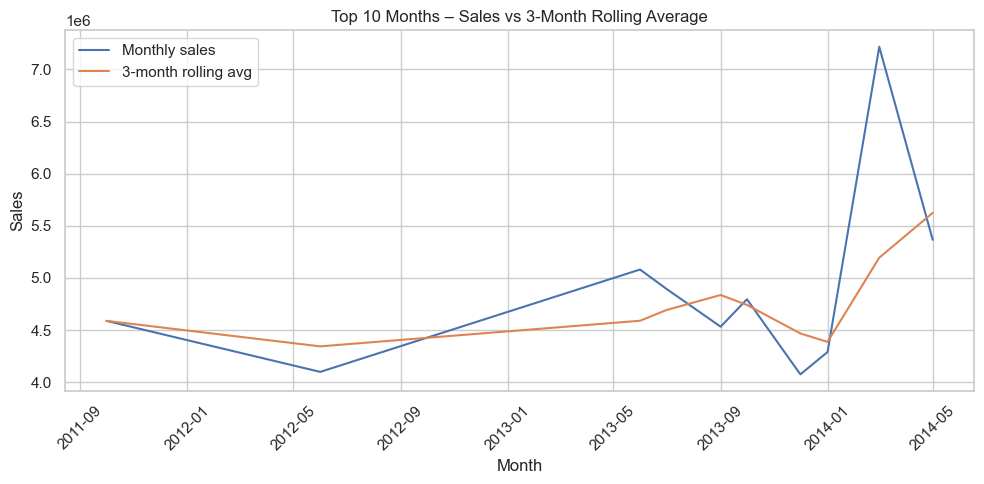

In [138]:
fig, ax = plt.subplots()

ax.plot(df_monthly_top10["MonthStart"], df_monthly_top10["TotalSales"], label="Monthly sales")
ax.plot(df_monthly_top10["MonthStart"], df_monthly_top10["Rolling3Sales"], label="3-month rolling avg")

ax.set_xlabel("Month")
ax.set_ylabel("Sales")
ax.set_title("Top 10 Months – Sales vs 3-Month Rolling Average")
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Top 10 months – trend vs volatility

This line chart compares actual monthly sales (blue) with a 3‑month rolling average (orange). The rolling line smooths short‑term spikes and dips, making it easier to see the underlying upward trend and how extreme certain peak months are relative to recent history.

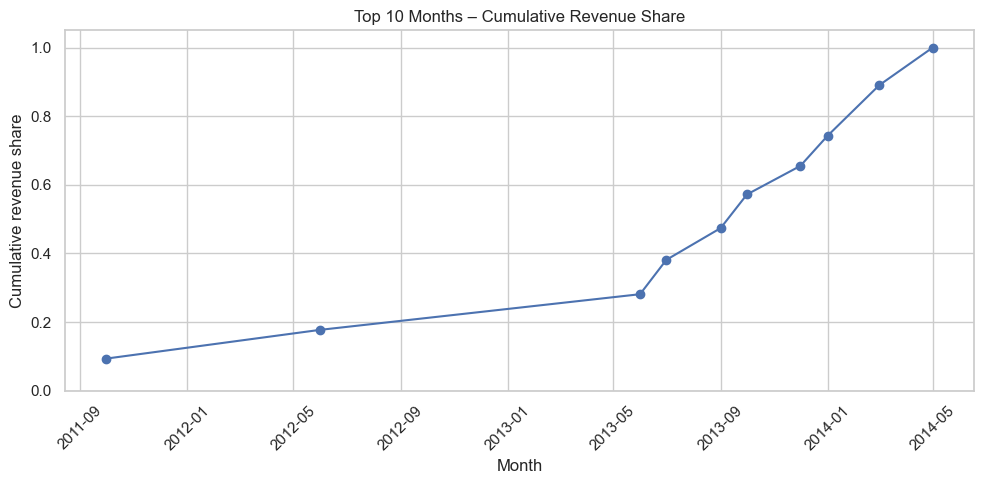

In [139]:
fig, ax = plt.subplots()

ax.plot(
    df_monthly_top10["MonthStart"],
    df_monthly_top10["CumulativeShare"],
    marker="o"
)

ax.set_xlabel("Month")
ax.set_ylabel("Cumulative revenue share")
ax.set_title("Top 10 Months – Cumulative Revenue Share")
ax.set_ylim(0, 1.05)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Top 10 months – cumulative revenue share

This chart shows how quickly revenue accumulates across the top 10 months. The curve rises slowly at first, then increases sharply in late 2013–2014, indicating that a few recent peak months contribute a disproportionately large share of total sales among these top months.

In [140]:
# Correlation between key numeric columns
product_corr = df_top_products[["TotalSales", "TotalQuantity", "OrderCount"]].corr()
product_corr

,TotalSales,TotalQuantity,OrderCount
TotalSales,1.00,0.98,0.98
TotalQuantity,0.98,1.00,0.98
OrderCount,0.98,0.98,1.00


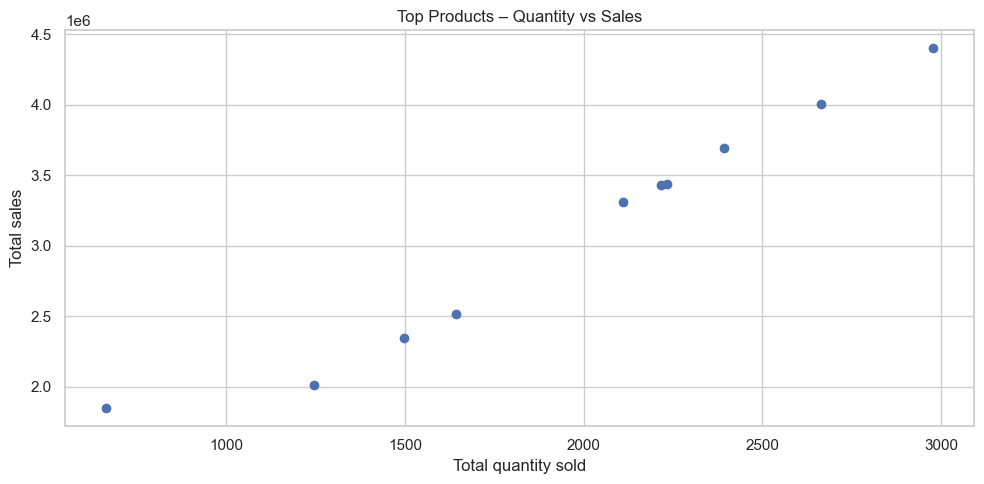

In [141]:
fig, ax = plt.subplots()

ax.scatter(
    df_top_products["TotalQuantity"],
    df_top_products["TotalSales"]
)

ax.set_xlabel("Total quantity sold")
ax.set_ylabel("Total sales")
ax.set_title("Top Products – Quantity vs Sales")

plt.tight_layout()
plt.show()

### Top products – quantity vs revenue

This scatter compares total units sold with total sales for the top products. The strong upward pattern shows that, within this group, higher revenue is closely tied to higher volume rather than isolated pricing effects. For management, this suggests that boosting unit sales of high‑potential products (through targeted promotions or cross‑sell) is a reliable lever for increasing revenue among our current leaders.

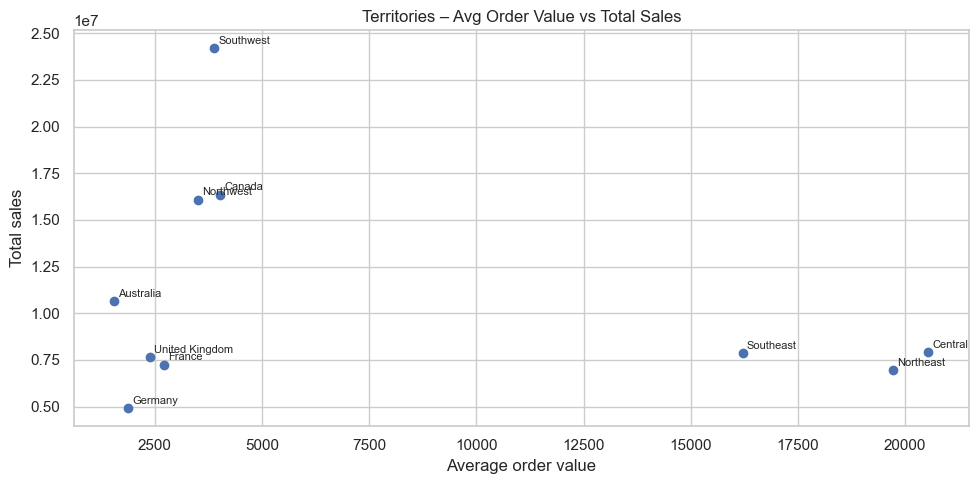

In [142]:
fig, ax = plt.subplots()

ax.scatter(
    df_territory_sales["AvgOrderValue"],
    df_territory_sales["TotalSales"]
)

for _, row in df_territory_sales.iterrows():
    ax.annotate(
        row["TerritoryName"],
        (row["AvgOrderValue"], row["TotalSales"]),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_xlabel("Average order value")
ax.set_ylabel("Total sales")
ax.set_title("Territories – Avg Order Value vs Total Sales")

plt.tight_layout()
plt.show()


### EDA highlights – top products, months, and territories

- Top products: High revenue is strongly tied to higher unit volume, and the High sales tier contributes the majority of revenue among the top 10 products.
- Top months: A few late months (late 2013–2014) account for most of the revenue within the top 10, as shown by the steep part of the cumulative share curve.
- Territories: Southwest delivers the highest total sales through strong volume at moderate order values, while Central and Northeast behave more like premium territories with higher average order values but lower overall revenue.

In [143]:
import pandas as pd

clean_df_sales_lines = pd.read_parquet(
    "../data/clean/clean_sales_lines.parquet",
    engine="fastparquet"
)
clean_df_sales_lines.head()


,OrderDate,ProductName,LineTotal,OrderQty,Status
0,2011-05-31,"Mountain-100 Black, 42","2,024.99",1,5
1,2011-05-31,"Mountain-100 Black, 44","6,074.98",3,5
2,2011-05-31,"Mountain-100 Black, 48","2,024.99",1,5
3,2011-05-31,"Mountain-100 Silver, 38","2,039.99",1,5
4,2011-05-31,"Mountain-100 Silver, 42","2,039.99",1,5


In [144]:
import pandas as pd

df = clean_df_sales_lines.copy()

# Ensure OrderDate is datetime
df["OrderDate"] = pd.to_datetime(df["OrderDate"])

# Basic calendar fields
df["order_year"] = df["OrderDate"].dt.year
df["order_quarter"] = df["OrderDate"].dt.to_period("Q").astype(str)  # e.g. '2014Q3'
df["order_month"] = df["OrderDate"].dt.month
df["order_month_name"] = df["OrderDate"].dt.month_name()

# Weekend vs weekday (Saturday=5, Sunday=6)
df["is_weekend"] = df["OrderDate"].dt.weekday >= 5

# Simple season mapping for Northern Hemisphere
def month_to_season(m):
    if m in (12, 1, 2):
        return "Winter"
    elif m in (3, 4, 5):
        return "Spring"
    elif m in (6, 7, 8):
        return "Summer"
    else:
        return "Fall"

df["order_season"] = df["order_month"].apply(month_to_season)

df.head()


,OrderDate,ProductName,LineTotal,OrderQty,Status,order_year,order_quarter,order_month,order_month_name,is_weekend,order_season
0,2011-05-31,"Mountain-100 Black, 42","2,024.99",1,5,2011,2011Q2,5,May,False,Spring
1,2011-05-31,"Mountain-100 Black, 44","6,074.98",3,5,2011,2011Q2,5,May,False,Spring
2,2011-05-31,"Mountain-100 Black, 48","2,024.99",1,5,2011,2011Q2,5,May,False,Spring
3,2011-05-31,"Mountain-100 Silver, 38","2,039.99",1,5,2011,2011Q2,5,May,False,Spring
4,2011-05-31,"Mountain-100 Silver, 42","2,039.99",1,5,2011,2011Q2,5,May,False,Spring


In [145]:
df = clean_df_sales_lines.copy()

# Normalize text just in case
df["ProductCategoryName"] = df["ProductCategoryName"].str.strip()
df["ProductSubcategoryName"] = df["ProductSubcategoryName"].str.strip()

# Example broad flags (adjust to your actual category names)
df["is_bike"] = df["ProductCategoryName"].eq("Bikes")
df["is_accessory"] = df["ProductCategoryName"].eq("Accessories")
df["is_clothing"] = df["ProductCategoryName"].eq("Clothing")
df["is_components"] = df["ProductCategoryName"].eq("Components")

# Example finer-grained flag using subcategory
df["is_mountain_bike"] = df["ProductSubcategoryName"].eq("Mountain Bikes")


KeyError: 'ProductCategoryName'